# Basic Details Analysis: Generation Statistics and Performance of the choosen LLM's

**How do different LLMs compare in terms of generation efficiency and performance across domains and prompting strategies?**

Extract and analyze basic generation details from JSON files for each run, model, and domain.

## Imports

In [1]:
from basic_details_analysis import *
from color_palette import *

# WARNINGS
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pkg_resources")

  1/81...
  11/81...
  21/81...
  31/81...
  41/81...
  51/81...
  61/81...
  71/81...
  81/81...


In [2]:
PROJECT_ROOT = find_project_root()
GENERATED_DIR = PROJECT_ROOT / "data" / "generated"
ANALYSIS_OUT_DIR = PROJECT_ROOT / "analysis" / "basic_details"
ANALYSIS_OUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = PROJECT_ROOT / "figures"

## Discover all generation summary JSON files

In [3]:
print(f"Found {len(summary_files)} generation summary files")
print(f"Models: {sorted(set(f['model'] for f in summary_files))}")
print(f"Domains: {sorted(set(f['domain'] for f in summary_files))}")
print(f"Shots: {sorted(set(f['shot'] for f in summary_files))}")
print(f"Runs: {sorted(set(f['run_num'] for f in summary_files if f['run_num'] is not None))}")

Found 81 generation summary files
Models: ['kimi-k2-instruct-0905', 'llama-3.1-8b-instruct', 'qwen3-coder-30b-a3b-instruct']
Domains: ['employment', 'hatecrime', 'lending']
Shots: ['few', 'one', 'zero']
Runs: [1, 2, 3]


## Basic details of the data generation from the chosen LLM's

In [4]:
print(f"\n=== BASIC DATA ===")
sample_cols = ['model', 'domain', 'shot_type', 'run_num', 'achieved_rows', 'duration_s', 'total_chunks', 'success_rate']
print("\n")
print(details_df[sample_cols].to_string(index=False))


=== BASIC DATA ===


                            model     domain shot_type  run_num  achieved_rows  duration_s  total_chunks  success_rate
 moonshotai/Kimi-K2-Instruct-0905 employment       few        1           1032      284.77            20      1.000000
 moonshotai/Kimi-K2-Instruct-0905 employment       one        1           1025      281.56            21      1.000000
 moonshotai/Kimi-K2-Instruct-0905 employment      zero        1           1043      247.53            22      1.000000
 moonshotai/Kimi-K2-Instruct-0905  hatecrime       few        1           1004      180.52            21      1.000000
 moonshotai/Kimi-K2-Instruct-0905  hatecrime       one        1           1000      167.57            21      1.000000
 moonshotai/Kimi-K2-Instruct-0905  hatecrime      zero        1           1042      168.43            22      1.000000
 moonshotai/Kimi-K2-Instruct-0905    lending       few        1           1035      430.42            24      1.000000
 moonshotai/Kimi-K2-Instru

## Time progression analysis

In [5]:
chunk_df = load_chunk_timing_data()

In [6]:
models_present = chunk_df['model'].unique() if 'chunk_df' in locals() else []
model_colors = {model: model_color(model) for model in models_present}

In [7]:
print("\n=== MODEL x SHOT: Average Time per Chunk ===")
model_shot_avg = (
    chunk_df.groupby(['model', 'shot_type'])['duration_s']
    .mean()
    .unstack('shot_type')
    .reindex(index=MODEL_ORDER, columns=SHOT_ORDER)
    .round(2)
)
print(model_shot_avg.to_string())


=== MODEL x SHOT: Average Time per Chunk ===
shot_type                      zero    one    few
model                                            
kimi-k2-instruct-0905         12.11  13.34  13.71
llama-3.1-8b-instruct         61.48  62.69  69.91
qwen3-coder-30b-a3b-instruct  45.13  46.57  48.03


In [8]:
print("="*80)
print("TIME PROGRESSION ACROSS CHUNKS")
print("="*80)

if len(chunk_df) > 0:
    # calculate average time per chunk across runs for each model
    chunk_timing = chunk_df.groupby(['model', 'chunk_id'])['duration_s'].mean().reset_index()
    models = ordered_levels(chunk_df['model'].unique(), MODEL_ORDER)
    domains = ordered_levels(chunk_df['domain'].unique(), DOMAIN_ORDER)
    shot_types = ordered_levels(chunk_df['shot_type'].unique(), SHOT_ORDER)
    
    print(f"\nChunk timing summary:")
    print(f"Models: {models}")
    print(f"Domains: {domains}")
    print(f"Shot types: {shot_types}")
    print(f"Runs per combination: {chunk_df.groupby(['model', 'domain', 'shot_type'])['run_num'].nunique().iloc[0]}")
    print(f"Chunk range: {chunk_df['chunk_id'].min()} to {chunk_df['chunk_id'].max()}")
    print(f"Average chunks per model: {chunk_df.groupby('model')['chunk_id'].nunique().mean():.1f}")
    print(f"Total chunks analyzed: {len(chunk_df)}")
    
    # show sample data
    print(f"\nChunk timing data (averaged across runs):")
    sample_cols = ['model', 'chunk_id', 'duration_s']
    print(chunk_timing[sample_cols].to_string(index=False))
    
else:
    print("No chunk timing data available")

TIME PROGRESSION ACROSS CHUNKS

Chunk timing summary:
Models: ['kimi-k2-instruct-0905', 'llama-3.1-8b-instruct', 'qwen3-coder-30b-a3b-instruct']
Domains: ['hatecrime', 'employment', 'lending']
Shot types: ['zero', 'one', 'few']
Runs per combination: 3
Chunk range: 1 to 29
Average chunks per model: 27.3
Total chunks analyzed: 1788

Chunk timing data (averaged across runs):
                       model  chunk_id  duration_s
       kimi-k2-instruct-0905         1   12.422593
       kimi-k2-instruct-0905         2   13.000741
       kimi-k2-instruct-0905         3   12.357778
       kimi-k2-instruct-0905         4   12.520000
       kimi-k2-instruct-0905         5   12.958519
       kimi-k2-instruct-0905         6   12.640370
       kimi-k2-instruct-0905         7   13.038148
       kimi-k2-instruct-0905         8   12.530000
       kimi-k2-instruct-0905         9   12.615185
       kimi-k2-instruct-0905        10   13.078148
       kimi-k2-instruct-0905        11   12.959630
       kimi-k

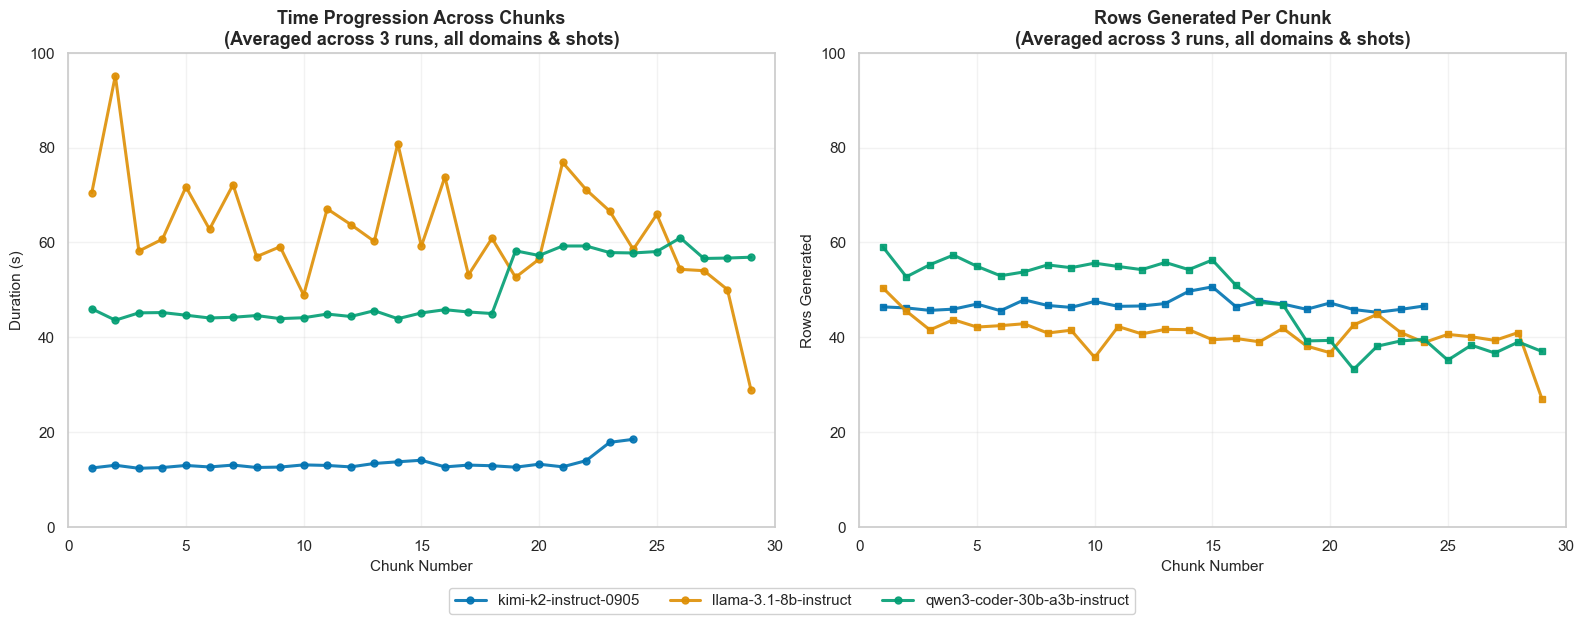


=== TIME PROGRESSION SUMMARY ===
kimi-k2-instruct-0905:
  First chunk: 12.4s, Last chunk: 18.5s
  Average time: 13.4s

llama-3.1-8b-instruct:
  First chunk: 70.5s, Last chunk: 28.9s
  Average time: 62.4s

qwen3-coder-30b-a3b-instruct:
  First chunk: 46.0s, Last chunk: 56.9s
  Average time: 49.8s


AVERAGE TIME PER MODEL, DOMAIN, AND SHOT COMBINATION

kimi-k2-instruct-0905
--------------------------------------------------------------------------------
Domain          Shot       Avg Time (s)    Avg per Domain 
--------------------------------------------------------------------------------
hatecrime       zero       7.48            7.95           
hatecrime       one        7.96            7.95           
hatecrime       few        8.44            7.95           

employment      zero       11.83           13.06          
employment      one        13.27           13.06          
employment      few        14.14           13.06          

lending         zero       16.65           17.6

In [9]:
if len(chunk_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax1, ax2 = axes
    model_sequence = ordered_levels(chunk_df['model'].unique(), MODEL_ORDER)

    for model in model_sequence:
        model_data = chunk_timing[chunk_timing['model'] == model]
        if len(model_data) > 0:
            ax1.plot(
                model_data['chunk_id'], model_data['duration_s'],
                marker='o', markersize=5, linewidth=2.2,
                color=model_colors[model], label=model, alpha=0.9
            )

    ax1.set_title('Time Progression Across Chunks\n(Averaged across 3 runs, all domains & shots)',
                  fontweight='bold', fontsize=13)
    ax1.set_xlabel('Chunk Number', fontsize=11)
    ax1.set_ylabel('Duration (s)', fontsize=11)
    ax1.grid(alpha=0.25)
    ax1.set_xlim(left=0, right=30)
    ax1.set_ylim(bottom=0, top=100)

    chunk_rows = chunk_df.groupby(['model', 'chunk_id'])['rows_generated'].mean().reset_index()
    for model in model_sequence:
        model_data = chunk_rows[chunk_rows['model'] == model]
        if len(model_data) > 0:
            ax2.plot(
                model_data['chunk_id'], model_data['rows_generated'],
                marker='s', markersize=5, linewidth=2.2,
                color=model_colors[model], label=model, alpha=0.9
            )

    ax2.set_title('Rows Generated Per Chunk\n(Averaged across 3 runs, all domains & shots)',
                  fontweight='bold', fontsize=13)
    ax2.set_xlabel('Chunk Number', fontsize=11)
    ax2.set_ylabel('Rows Generated', fontsize=11)
    ax2.grid(alpha=0.25)
    ax2.set_xlim(left=0, right=30)
    ax2.set_ylim(bottom=0, top=100)
    ax2.set_ylim(bottom=0, top=100)
    
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(
        handles, labels,
        ncol=len(labels),
        loc='lower center',
        bbox_to_anchor=(0.5, -0.05),
        frameon=True,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "time_progression_accros_chunks_and_rows_generated_per_chunk.png", bbox_inches='tight')
    plt.show()

    print(f"\n=== TIME PROGRESSION SUMMARY ===")
    for model in model_sequence:
        model_data = chunk_timing[chunk_timing['model'] == model]
        if len(model_data) > 1:
            first_chunk_time = model_data.loc[model_data['chunk_id'].idxmin(), 'duration_s']
            last_chunk_time = model_data.loc[model_data['chunk_id'].idxmax(), 'duration_s']
            avg_time = model_data['duration_s'].mean()

            print(f"{model}:")
            print(f"  First chunk: {first_chunk_time:.1f}s, Last chunk: {last_chunk_time:.1f}s")
            print(f"  Average time: {avg_time:.1f}s\n")
    
    print("\n" + "="*80)
    print("AVERAGE TIME PER MODEL, DOMAIN, AND SHOT COMBINATION")
    print("="*80)
    
    avg_times = chunk_df.groupby(['model', 'domain', 'shot_type'])['duration_s'].mean().reset_index()
    avg_times.columns = ['Model', 'Domain', 'Shot', 'Avg Time (s)']
    
    domain_avg = chunk_df.groupby(['model', 'domain'])['duration_s'].mean().reset_index()
    domain_avg.columns = ['Model', 'Domain', 'Avg per Domain']
    
    model_chunk_avg = chunk_df.groupby(['model', 'chunk_id'])['duration_s'].mean().reset_index()
    model_avg = model_chunk_avg.groupby('model')['duration_s'].mean().reset_index()
    model_avg.columns = ['Model', 'Overall Avg']
    
    result_df = avg_times.merge(domain_avg, on=['Model', 'Domain'], how='left')
    result_df = result_df.merge(model_avg, on='Model', how='left')
    
    result_df['Avg Time (s)'] = result_df['Avg Time (s)'].round(2)
    result_df['Avg per Domain'] = result_df['Avg per Domain'].round(2)
    result_df['Overall Avg'] = result_df['Overall Avg'].round(2)
    
    result_df['Domain'] = pd.Categorical(result_df['Domain'], categories=DOMAIN_ORDER, ordered=True)
    result_df['Shot'] = pd.Categorical(result_df['Shot'], categories=SHOT_ORDER, ordered=True)
    result_df['Model'] = pd.Categorical(result_df['Model'], categories=MODEL_ORDER, ordered=True)
    result_df = result_df.sort_values(['Model', 'Domain', 'Shot'])
    
    models = result_df['Model'].unique()
    for model in models:
        model_data = result_df[result_df['Model'] == model]
        overall_avg = model_data['Overall Avg'].iloc[0]
        
        print(f"\n{model}")
        print("-" * 80)
        print(f"{'Domain':<15} {'Shot':<10} {'Avg Time (s)':<15} {'Avg per Domain':<15}")
        print("-" * 80)
        
        current_domain = None
        for _, row in model_data.iterrows():
            domain = row['Domain']
            shot = row['Shot']
            avg_time = row['Avg Time (s)']
            avg_per_domain = row['Avg per Domain']
            
            if domain != current_domain:
                if current_domain is not None:
                    print() 
                current_domain = domain
            
            print(f"{domain:<15} {shot:<10} {avg_time:<15.2f} {avg_per_domain:<15.2f}")
        
        print("-" * 80)
        print(f"{'Overall model average (s)':<50} {overall_avg:.2f}")
        print()

else:
    print("Cannot generate time progression plots - no chunk data available")

TIME PROGRESSION BY DOMAIN AND SHOT TYPE
(Averaged across 3 runs for each model/domain/shot combination)


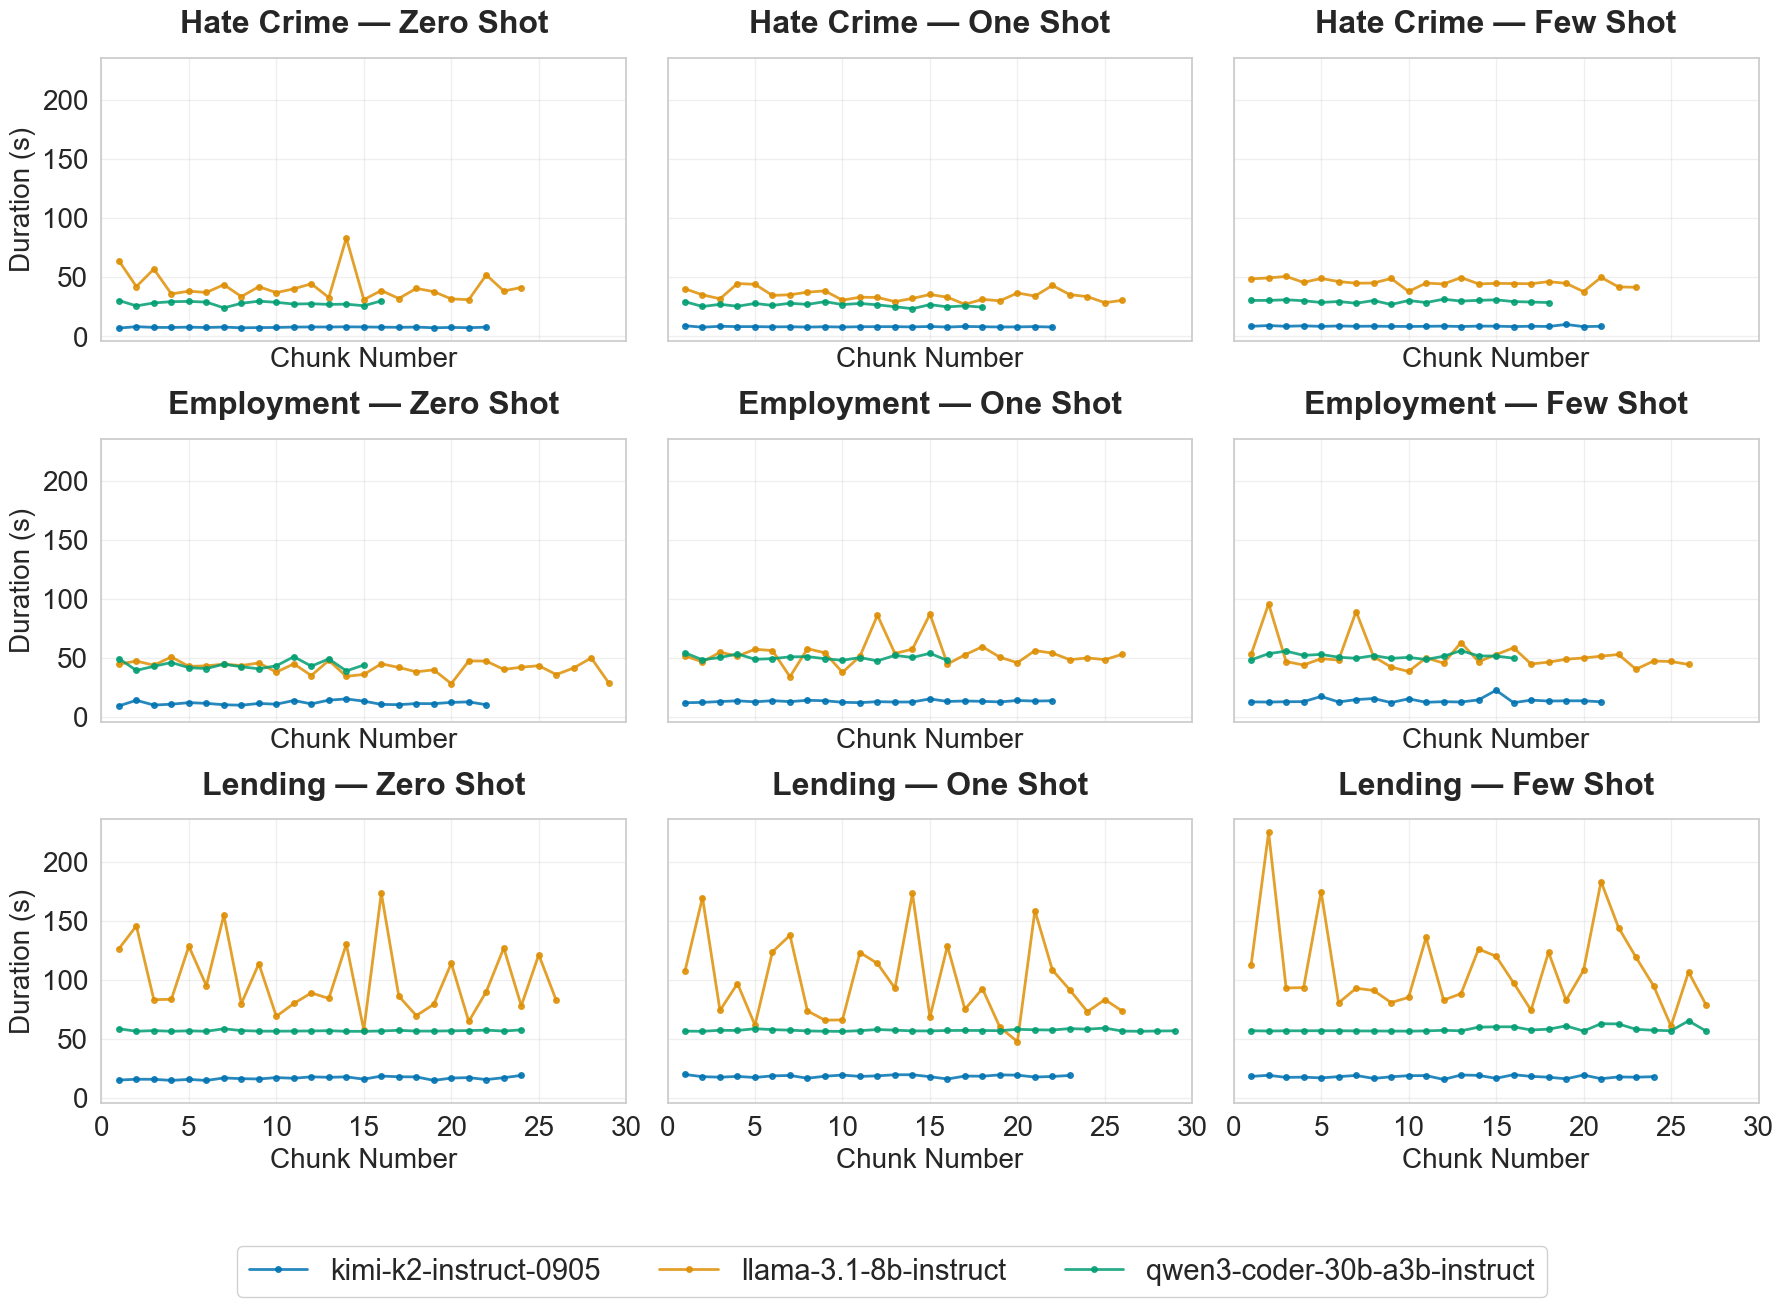


=== TIME PROGRESSION PATTERNS ===
                       model     domain shot  first_chunk_s  last_chunk_s
       kimi-k2-instruct-0905  hatecrime zero           6.81          7.55
       kimi-k2-instruct-0905  hatecrime  one           8.80          7.70
       kimi-k2-instruct-0905  hatecrime  few           8.33          8.34
       kimi-k2-instruct-0905 employment zero           9.45         10.46
       kimi-k2-instruct-0905 employment  one          12.13         13.82
       kimi-k2-instruct-0905 employment  few          12.85         12.91
       kimi-k2-instruct-0905    lending zero          15.20         19.10
       kimi-k2-instruct-0905    lending  one          19.91         19.09
       kimi-k2-instruct-0905    lending  few          18.30         18.05
       llama-3.1-8b-instruct  hatecrime zero          63.84         41.15
       llama-3.1-8b-instruct  hatecrime  one          40.08         30.35
       llama-3.1-8b-instruct  hatecrime  few          48.48         41.37
   

In [10]:
plt.rcParams.update({
    'axes.titlesize': 23,
    'axes.labelsize': 20,
    'legend.fontsize': 21,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'figure.titlesize': 30,
    'axes.titlepad': 18,
})

if len(chunk_df) > 0:
    print("="*80)
    print("TIME PROGRESSION BY DOMAIN AND SHOT TYPE")
    print("(Averaged across 3 runs for each model/domain/shot combination)")
    print("="*80)
    
    domains = ordered_levels(chunk_df['domain'].unique(), DOMAIN_ORDER)
    shot_types = ordered_levels(chunk_df['shot_type'].unique(), SHOT_ORDER)
    
    fig, axes = plt.subplots(
        len(domains), len(shot_types),
        figsize=(18, 12),
        sharex=True, sharey=True
    )
    
    if len(domains) == 1 and len(shot_types) == 1:
        axes = [[axes]]
    elif len(domains) == 1:
        axes = [axes]
    elif len(shot_types) == 1:
        axes = [[ax] for ax in axes]

    for row, domain in enumerate(domains):
        for col, shot in enumerate(shot_types):
            ax = axes[row][col]
            domain_shot_data = chunk_df[(chunk_df['domain'] == domain) & (chunk_df['shot_type'] == shot)]
            
            if len(domain_shot_data) > 0:
                domain_shot_timing = (
                    domain_shot_data.groupby(['model', 'chunk_id'])['duration_s']
                    .mean()
                    .reset_index()
                )

                for model in ordered_levels(domain_shot_data['model'].unique(), MODEL_ORDER):
                    model_data = domain_shot_timing[domain_shot_timing['model'] == model]
                    ax.plot(
                        model_data['chunk_id'], model_data['duration_s'],
                        marker='o', linewidth=2, markersize=4,
                        label=model, color=model_colors[model], alpha=0.85
                    )
                
                ax.set_title(f'{format_domain_name(domain)} — {shot.title()} Shot', weight='bold')
                ax.set_xlabel('Chunk Number')
                if col == 0:  # Only show y-axis label on first column (zero shot)
                    ax.set_ylabel('Duration (s)')
                ax.grid(True, which='major', alpha=0.3)
                ax.set_xlim(left=0, right=30)
                
            else:
                ax.set_title(f'{format_domain_name(domain)} — {shot.title()} Shot', weight='bold')
                ax.text(
                    0.5, 0.5, 'No data available',
                    ha='center', va='center', fontsize=9, color='gray', transform=ax.transAxes
                )
                ax.set_xticks([])
                ax.set_yticks([])

    # fig.suptitle(
    #     "Time Progression by Domain and Shot Type (Averaged Across 3 Runs)",
    #     weight='bold',
    #     fontsize=15
    # )
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, labels,
        ncol=len(labels),
        loc='lower center',
        bbox_to_anchor=(0.5, -0.10),
        frameon=True,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "time_progression_by_domain_shot.png", bbox_inches='tight')
    plt.show()
    
    # summary table for time progression patterns
    print(f"\n=== TIME PROGRESSION PATTERNS ===")
    progression_summary = []
    
    for model in ordered_levels(chunk_df['model'].unique(), MODEL_ORDER):
        for domain in domains:
            for shot in shot_types:
                domain_shot_data = chunk_df[(chunk_df['model'] == model) & 
                                          (chunk_df['domain'] == domain) & 
                                          (chunk_df['shot_type'] == shot)]
                
                if len(domain_shot_data) > 1:
                    chunk_timing = domain_shot_data.groupby('chunk_id')['duration_s'].mean()
                    if len(chunk_timing) > 1:
                        first_time = chunk_timing.iloc[0]
                        last_time = chunk_timing.iloc[-1]
                        avg_time = chunk_timing.mean()
                        
                        progression_summary.append({
                            'model': model,
                            'domain': domain,
                            'shot': shot,
                            'first_chunk_s': first_time.round(2),
                            'last_chunk_s': last_time.round(2),
                            # 'avg_time_s': avg_time.round(2),
                        })
    
    if progression_summary:
        progression_df = pd.DataFrame(progression_summary)
        print(progression_df.to_string(index=False))
        
        progression_file = ANALYSIS_OUT_DIR / "time_progression_analysis.csv"
        progression_df.to_csv(progression_file, index=False)
    else:
        print("No time progression data available for analysis")
else:
    print("No chunk data available for time progression analysis")

## Row Generation Analysis

**Key Questions**:
- How many rows did each model generate per domain/shot?
- Did models achieve their target row counts?
- How consistent are row counts across runs?


In [11]:
# row generation summary by model, domain, and shot
print("=== ROW GENERATION SUMMARY ===")

# overall summary
row_summary = details_df.groupby(['model', 'domain', 'shot_type']).agg({
    'achieved_rows': ['mean', 'std', 'min', 'max', 'count'],
    'target_rows': 'first',
    'duration_s': ['mean', 'std']
}).round(2)

print("\nRows Generated (Mean ± Std, Min-Max, Count):")
print(row_summary.to_string())

# target achievement analysis of rows
details_df['target_achievement'] = details_df['achieved_rows'] / details_df['target_rows']
print(f"\n=== TARGET ACHIEVEMENT ===")
target_achievement = details_df.groupby(['model', 'domain', 'shot_type'])['target_achievement'].agg(['mean', 'std', 'min', 'max']).round(3)
print(target_achievement.to_string())

# consistency across runs the runs in row generation
print(f"\n=== CONSISTENCY ACROSS RUNS ===")
consistency = details_df.groupby(['model', 'domain', 'shot_type'])['achieved_rows'].agg(['std', 'mean']).round(2)
consistency['cv'] = (consistency['std'] / consistency['mean'] * 100).round(2)
consistency = consistency.sort_values('cv')
print("Coefficient of Variation (CV) - Lower = More Consistent:")
print(consistency[['cv']].to_string())


=== ROW GENERATION SUMMARY ===

Rows Generated (Mean ± Std, Min-Max, Count):
                                                       achieved_rows                          target_rows duration_s        
                                                                mean    std   min   max count       first       mean     std
model                             domain     shot_type                                                                      
Qwen/Qwen3-Coder-30B-A3B-Instruct employment few             1049.33  17.56  1031  1066     3        1000     825.71    6.43
                                             one             1030.00  18.19  1019  1051     3        1000     807.21   10.97
                                             zero            1018.33   8.50  1010  1027     3        1000     659.28   33.86
                                  hatecrime  few             1035.67   3.79  1033  1040     3        1000     530.89    6.14
                                             one

## Average chunks used by model per domain and shot type

In [12]:
print("="*80)
print("AVERAGE CHUNKS USED BY MODEL PER DOMAIN AND SHOT TYPE")
print("="*80)

if len(details_df) > 0:
    # calculating average chunks by model, domain, and shot type
    chunks_analysis = details_df.groupby(['model', 'domain', 'shot_type']).agg({
        'total_chunks': ['mean', 'std', 'min', 'max', 'count']
    }).round(2)
    
    chunks_analysis.columns = ['_'.join(col).strip('_') for col in chunks_analysis.columns]
    
    print("Average chunks used (Mean ± Std, Min-Max, Count):")
    print(chunks_analysis.to_string())
    
    # creating pivot table for easier reading
    print(f"\n=== PIVOT TABLE: Average Chunks by Model and Domain ===")
    chunks_pivot = details_df.groupby(['model', 'domain'])['total_chunks'].mean().unstack().round(2)
    print("Employment | Hatecrime | Lending")
    print(chunks_pivot.to_string())
    
    print(f"\n=== PIVOT TABLE: Average Chunks by Model and Shot Type ===")
    chunks_shot_pivot = details_df.groupby(['model', 'shot_type'])['total_chunks'].mean().unstack().round(2)
    print("Zero-shot | One-shot | Few-shot")
    print(chunks_shot_pivot.to_string())
    
    # detailed breakdown by domain and shot type
    print(f"\n=== DETAILED BREAKDOWN ===")
    for domain in sorted(details_df['domain'].unique()):
        print(f"\n{domain.upper()} DOMAIN:")
        domain_data = details_df[details_df['domain'] == domain]
        domain_chunks = domain_data.groupby(['model', 'shot_type'])['total_chunks'].mean().unstack().round(2)
        print(domain_chunks.to_string())
    
    # summary statistics
    print(f"\n=== SUMMARY STATISTICS ===")
    overall_stats = details_df.groupby('model')['total_chunks'].agg(['mean', 'std', 'min', 'max']).round(2)
    print("Overall chunks per model:")
    print(overall_stats.to_string())
    
    # domain specific statistics
    print(f"\nChunks by domain:")
    domain_stats = details_df.groupby('domain')['total_chunks'].agg(['mean', 'std']).round(2)
    print(domain_stats.to_string())
    
    # shot type statistics
    print(f"\nChunks by shot type:")
    shot_stats = details_df.groupby('shot_type')['total_chunks'].agg(['mean', 'std']).round(2)
    print(shot_stats.to_string())
    
    # saving chunks analysis
    chunks_file = ANALYSIS_OUT_DIR / "chunks_analysis.csv"
    chunks_analysis.to_csv(chunks_file)
else:
    print("No data available for chunks analysis")

AVERAGE CHUNKS USED BY MODEL PER DOMAIN AND SHOT TYPE
Average chunks used (Mean ± Std, Min-Max, Count):
                                                        total_chunks_mean  total_chunks_std  total_chunks_min  total_chunks_max  total_chunks_count
model                             domain     shot_type                                                                                             
Qwen/Qwen3-Coder-30B-A3B-Instruct employment few                    16.00              0.00                16                16                   3
                                             one                    16.00              0.00                16                16                   3
                                             zero                   15.00              0.00                15                15                   3
                                  hatecrime  few                    18.00              0.00                18                18                   3
        

In [13]:
print("\n=== OVERALL AVERAGE CHUNKS BY MODEL × DOMAIN ===")
overall_avg_chunks = (
    details_df.groupby(['model', 'domain'])['total_chunks']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .rename(columns={
        'mean': 'avg_chunks',
        'std': 'std_chunks',
        'min': 'min_chunks',
        'max': 'max_chunks',
        'count': 'runs'
    })
    .round(2)
)
print("Average total chunks per model-domain combination (aggregated across all shots and runs):")
print(overall_avg_chunks.to_string())


=== OVERALL AVERAGE CHUNKS BY MODEL × DOMAIN ===
Average total chunks per model-domain combination (aggregated across all shots and runs):
                                              avg_chunks  std_chunks  min_chunks  max_chunks  runs
model                             domain                                                          
Qwen/Qwen3-Coder-30B-A3B-Instruct employment       15.67        0.50          15          16     9
                                  hatecrime        17.11        1.36          15          18     9
                                  lending          26.33        1.87          24          29     9
meta-llama/Llama-3.1-8B-Instruct  employment       26.11        1.54          24          29     9
                                  hatecrime        23.00        1.87          19          26     9
                                  lending          25.00        1.22          23          27     9
moonshotai/Kimi-K2-Instruct-0905  employment       20.89        0.93

## Quality of Rows generated

In [14]:
raw_analysis_df = analyze_raw_finals_comprehensive()

In [15]:
if not raw_analysis_df.empty:
    total_original_rows = raw_analysis_df['total_data_rows'].sum()
    total_pandas_rows = raw_analysis_df['pandas_readable_rows'].sum()
    total_lost = raw_analysis_df['total_rows_lost'].sum()
    print(f"Total original data rows: {total_original_rows:,}")
    print(f"Total pandas-readable rows: {total_pandas_rows:,}")
    print(f"Total rows lost: {total_lost:,}")
    print(f"Overall skip rate: {(total_lost/total_original_rows*100):.2f}%")

    print("\n=== BY MODEL ===")
    model_summary = raw_analysis_df.groupby('model').agg({
        'total_data_rows': 'sum',
        'pandas_readable_rows': 'sum',
        'total_rows_lost': 'sum',
    })
    print(model_summary)

    print("\n=== BY MODEL x RUN ===")
    model_run_summary = raw_analysis_df.groupby(['model', 'run_num']).agg({
        'total_data_rows': 'sum',
        'pandas_readable_rows': 'sum',
        'total_rows_lost': 'sum',
    })
    print(model_run_summary)

    print("\n--- Rows lost (pivot) — Model x Run ---")
    model_run_loss_pivot = raw_analysis_df.pivot_table(
        values='total_rows_lost', index='model', columns='run_num', aggfunc='sum', fill_value=0
    )
    print(model_run_loss_pivot)

    raw_analysis_df.to_csv(ANALYSIS_OUT_DIR / 'raw_finals_comprehensive_analysis.csv', index=False)
else:
    print('No raw_finals files found.')

Total original data rows: 84,235
Total pandas-readable rows: 72,247
Total rows lost: 11,988
Overall skip rate: 14.23%

=== BY MODEL ===
                              total_data_rows  pandas_readable_rows  \
model                                                                 
kimi-k2-instruct-0905                   27773                 26254   
llama-3.1-8b-instruct                   28681                 22501   
qwen3-coder-30b-a3b-instruct            27781                 23492   

                              total_rows_lost  
model                                          
kimi-k2-instruct-0905                    1519  
llama-3.1-8b-instruct                    6180  
qwen3-coder-30b-a3b-instruct             4289  

=== BY MODEL x RUN ===
                                      total_data_rows  pandas_readable_rows  \
model                        run_num                                          
kimi-k2-instruct-0905        1                   9254                  8961   
       

In [16]:
print("\n=== DETAILED BREAKDOWN (Model x Domain x Shot) ===")
detailed_summary = raw_analysis_df.groupby(['model', 'domain', 'shot_type']).agg({
    'total_data_rows': 'mean',
    'pandas_readable_rows': 'mean',
    'total_rows_lost': 'mean',
}).round(1)
print(detailed_summary)


=== DETAILED BREAKDOWN (Model x Domain x Shot) ===
                                                   total_data_rows  \
model                        domain     shot_type                    
kimi-k2-instruct-0905        employment few                 1027.7   
                                        one                 1037.3   
                                        zero                1030.0   
                             hatecrime  few                 1007.7   
                                        one                 1016.7   
                                        zero                1035.7   
                             lending    few                 1033.0   
                                        one                 1026.0   
                                        zero                1043.7   
llama-3.1-8b-instruct        employment few                 1006.7   
                                        one                 1019.3   
                                      

In [17]:
print("\n=== DETAILED BREAKDOWN (Model x Run x Domain x Shot) ===")
detailed_run_summary = raw_analysis_df.groupby(['model', 'run_num', 'domain', 'shot_type']).agg({
    'total_data_rows': 'mean',
    'pandas_readable_rows': 'mean',
    'total_rows_lost': 'mean',
})
print(detailed_run_summary)


=== DETAILED BREAKDOWN (Model x Run x Domain x Shot) ===
                                                           total_data_rows  \
model                        run_num domain     shot_type                    
kimi-k2-instruct-0905        1       employment few                 1032.0   
                                                one                 1026.0   
                                                zero                1043.0   
                                     hatecrime  few                 1004.0   
                                                one                 1000.0   
...                                                                    ...   
qwen3-coder-30b-a3b-instruct 3       hatecrime  one                 1050.0   
                                                zero                1078.0   
                                     lending    few                 1013.0   
                                                one                 1015.0   
      

In [18]:
if not raw_analysis_df.empty:    

    print("\n" + "="*80)
    print("ROWS LOST SUMMARY TABLES")
    print("="*80)
    
    # total rows lost by Model
    print("\n--- Rows Lost by Model ---")
    model_loss = raw_analysis_df.groupby('model')['total_rows_lost'].sum().reset_index()
    model_loss.columns = ['Model', 'Total Rows Lost']
    model_loss = model_loss.sort_values('Total Rows Lost', ascending=False)
    print(model_loss.to_string(index=False))
    
    # total rows lost by Domain
    print("\n--- Rows Lost by Domain ---")
    domain_loss = raw_analysis_df.groupby('domain')['total_rows_lost'].sum().reset_index()
    domain_loss.columns = ['Domain', 'Total Rows Lost']
    domain_loss = domain_loss.sort_values('Total Rows Lost', ascending=False)
    print(domain_loss.to_string(index=False))
    
    # total rows lost by Shot Type
    print("\n--- Rows Lost by Shot Type ---")
    shot_loss = raw_analysis_df.groupby('shot_type')['total_rows_lost'].sum().reset_index()
    shot_loss.columns = ['Shot Type', 'Total Rows Lost']
    shot_loss = shot_loss.sort_values('Total Rows Lost', ascending=False)
    print(shot_loss.to_string(index=False))
    
    # fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    # pivot_loss = raw_analysis_df.groupby(['model', 'domain'])['total_rows_lost'].sum().unstack(fill_value=0)
    # sns.heatmap(pivot_loss, annot=True, fmt='d', cmap='Reds', ax=ax)
    # ax.set_title('Rows Lost: Model x Domain')
    # ax.set_xlabel('Domain')
    # ax.set_ylabel('Model')
    # ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=15)
    # plt.tight_layout()
    # plt.savefig(FIGURES_DIR / "rows_lost_by_model_domain.png", bbox_inches='tight')
    # plt.show()
    
    print("\n" + "="*100)
    print("DETAILED COMPARISON TABLE")
    print("="*100)
    comparison_table = raw_analysis_df.groupby(['model', 'domain', 'shot_type']).agg({
        'total_data_rows': 'mean',
        'pandas_readable_rows': 'mean',
        'total_rows_lost': 'mean',
    }).round(1)
    comparison_table['rows_lost_pct'] = ((comparison_table['total_rows_lost'] / comparison_table['total_data_rows']) * 100).round(2)
    print(comparison_table.to_string())
    
    print(f"\n" + "="*100)
    print("KEY INSIGHTS")
    print("="*100)
    worst_model = raw_analysis_df.groupby('model')['total_rows_lost'].sum().idxmax()
    worst_domain = raw_analysis_df.groupby('domain')['total_rows_lost'].sum().idxmax()
    worst_shot = raw_analysis_df.groupby('shot_type')['total_rows_lost'].sum().idxmax()
    print(f"WORST PERFORMERS (Most Data Loss):")
    print(f"   Model: {worst_model} ({raw_analysis_df.groupby('model')['total_rows_lost'].sum()[worst_model]} rows lost)")
    print(f"   Domain: {worst_domain} ({raw_analysis_df.groupby('domain')['total_rows_lost'].sum()[worst_domain]} rows lost)")
    print(f"   Shot Type: {worst_shot} ({raw_analysis_df.groupby('shot_type')['total_rows_lost'].sum()[worst_shot]} rows lost)")
    
else:
    print("No data available for visualization")


ROWS LOST SUMMARY TABLES

--- Rows Lost by Model ---
                       Model  Total Rows Lost
       llama-3.1-8b-instruct             6180
qwen3-coder-30b-a3b-instruct             4289
       kimi-k2-instruct-0905             1519

--- Rows Lost by Domain ---
    Domain  Total Rows Lost
   lending             6485
 hatecrime             4692
employment              811

--- Rows Lost by Shot Type ---
Shot Type  Total Rows Lost
      few             4779
      one             3917
     zero             3292

DETAILED COMPARISON TABLE
                                                   total_data_rows  pandas_readable_rows  total_rows_lost  rows_lost_pct
model                        domain     shot_type                                                                       
kimi-k2-instruct-0905        employment few                 1027.7                1026.0              1.7           0.17
                                        one                 1037.3                1025.7   